<h1 align="center"> Statistics and Financial Data Analysis </h1>



In [1]:
import pandas_datareader as pd_data
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import math as m
import scipy as sp
import datetime

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.metrics import r2_score, classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.metrics import homogeneity_score, silhouette_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, RandomForestRegressor, BaggingRegressor, BaggingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import MiniBatchKMeans, DBSCAN
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error


# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Hitters.csv')
df = df.dropna()
df['logSalary'] = np.log(df['Salary'])

In [3]:
df.head(10)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague,logSalary
1,315,81,7,24,38,39,14,3449,835,69,...,414,375,N,W,632,43,10,475.000,N,6.163315
2,479,130,18,66,72,76,3,1624,457,63,...,266,263,A,W,880,82,14,480.000,A,6.173786
3,496,141,20,65,78,37,11,5628,1575,225,...,838,354,N,E,200,11,3,500.000,N,6.214608
4,321,87,10,39,42,30,2,396,101,12,...,46,33,N,E,805,40,4,91.500,N,4.516339
5,594,169,4,74,51,35,11,4408,1133,19,...,336,194,A,W,282,421,25,750.000,A,6.620073
6,185,37,1,23,8,21,2,214,42,1,...,9,24,N,E,76,127,7,70.000,A,4.248495
7,298,73,0,24,24,7,3,509,108,0,...,37,12,A,W,121,283,9,100.000,A,4.605170
8,323,81,6,26,32,8,2,341,86,6,...,34,8,N,W,143,290,19,75.000,N,4.317488
9,401,92,17,49,66,65,13,5206,1332,253,...,890,866,A,E,0,0,0,1100.000,A,7.003065
10,574,159,21,107,75,59,10,4631,1300,90,...,504,488,A,E,238,445,22,517.143,A,6.248319


In [4]:
R1 = df[df['Years']>4.5]
R1['logSalary'].mean()

6.3540358427830235

In [5]:
R2 = df[df['Years']<=4.5]
R2['logSalary'].mean()

5.1067896059973705

In [6]:
R3 = df[(df['Years']>4.5)&(df['Hits']>=117.5)]
R3['logSalary'].mean()

6.739686922104511

In [7]:
R4 = df[(df['Years']>4.5)&(df['Hits']<117.5)]
R4['logSalary'].mean()

5.9983798474087635

In [8]:
df.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague', 'logSalary'],
      dtype='object')

In [9]:
X = df[['Years','Hits']].values
y = df['logSalary'].values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = DecisionTreeRegressor(max_depth=2)
model = model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test, y_pred))

0.5741315737021508
0.3611815340241412


In [11]:
df.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague', 'logSalary'],
      dtype='object')

In [12]:
newdf = df[['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks',
       'PutOuts', 'Assists', 'Errors']]

X = df[['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks',
       'PutOuts', 'Assists', 'Errors']].values
y = df['logSalary'].values

In [13]:
X.shape

(263, 16)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = DecisionTreeRegressor(max_depth=4)
model = model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test, y_pred))

0.8075423558175634
0.16322446762434673


[Text(0.48, 0.9, 'X[7] <= 1407.5\nsquared_error = 0.761\nsamples = 184\nvalue = 5.912'),
 Text(0.22, 0.7, 'X[7] <= 728.5\nsquared_error = 0.334\nsamples = 71\nvalue = 5.092'),
 Text(0.08, 0.5, 'X[1] <= 14.0\nsquared_error = 0.326\nsamples = 37\nvalue = 4.766'),
 Text(0.04, 0.3, 'squared_error = 0.0\nsamples = 1\nvalue = 7.663'),
 Text(0.12, 0.3, 'X[11] <= 51.0\nsquared_error = 0.096\nsamples = 36\nvalue = 4.685'),
 Text(0.08, 0.1, 'squared_error = 0.068\nsamples = 25\nvalue = 4.551'),
 Text(0.16, 0.1, 'squared_error = 0.023\nsamples = 11\nvalue = 4.991'),
 Text(0.36, 0.5, 'X[0] <= 465.0\nsquared_error = 0.101\nsamples = 34\nvalue = 5.447'),
 Text(0.28, 0.3, 'X[11] <= 121.5\nsquared_error = 0.07\nsamples = 24\nvalue = 5.576'),
 Text(0.24, 0.1, 'squared_error = 0.027\nsamples = 12\nvalue = 5.403'),
 Text(0.32, 0.1, 'squared_error = 0.053\nsamples = 12\nvalue = 5.749'),
 Text(0.44, 0.3, 'X[13] <= 322.5\nsquared_error = 0.041\nsamples = 10\nvalue = 5.137'),
 Text(0.4, 0.1, 'squared_error =

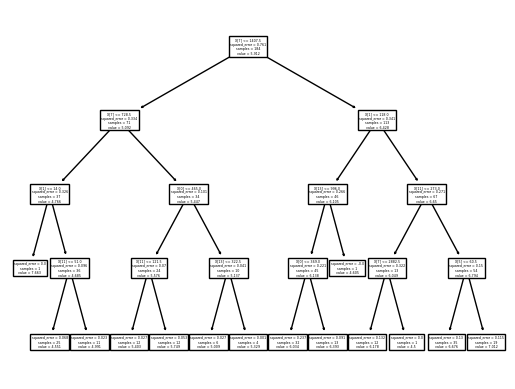

In [15]:
 tree.plot_tree(model)

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

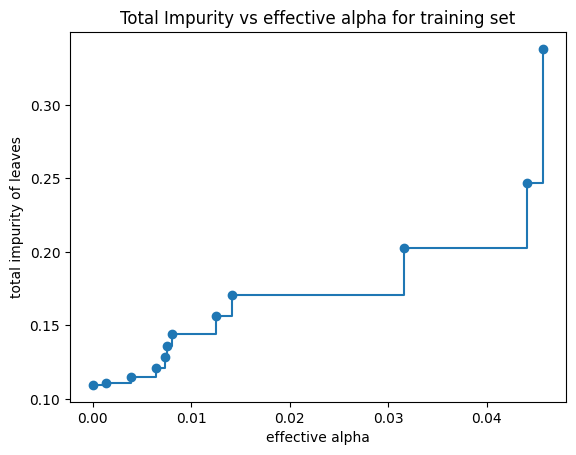

In [16]:
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = BaggingRegressor()
model = model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test, y_pred))

0.7982102581690569
0.17113907489789304


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = RandomForestRegressor()
model = model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test, y_pred))

0.8290562391882286
0.14497841574822404


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = GradientBoostingRegressor()
model = model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test, y_pred))

0.8296903930961226
0.14444058606394414


In [20]:
df = pd.read_csv('CreditCardData.csv')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69095 entries, 0 to 69094
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  69095 non-null  int64  
 1   V1          69095 non-null  float64
 2   V2          69095 non-null  float64
 3   V3          69095 non-null  float64
 4   V4          69095 non-null  float64
 5   V5          69095 non-null  float64
 6   V6          69095 non-null  float64
 7   V7          69095 non-null  float64
 8   V8          69094 non-null  float64
 9   V9          69094 non-null  float64
 10  V10         69094 non-null  float64
 11  V11         69094 non-null  float64
 12  V12         69094 non-null  float64
 13  V13         69094 non-null  float64
 14  V14         69094 non-null  float64
 15  V15         69094 non-null  float64
 16  V16         69094 non-null  float64
 17  V17         69094 non-null  float64
 18  V18         69094 non-null  float64
 19  V19         69094 non-nul

In [22]:
df.tail()

,Unnamed: 0,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
69090,53259,0.845489,-0.806087,-0.209546,0.139194,0.249369,1.551142,-0.224103,0.448259,-1.487353,...,-0.507396,-1.278292,0.163394,-1.440123,-0.073772,-0.624666,0.065120,0.027810,164.50,0.0
69091,53259,1.345176,-0.770987,-0.006960,-0.803176,-0.696594,-0.147665,-0.616752,0.045896,-0.649960,...,0.015304,-0.108052,-0.168517,-0.531423,0.571569,-0.218131,-0.013759,-0.001292,50.24,0.0
69092,53260,1.224377,0.803353,0.129078,2.477846,0.278926,-0.816388,0.625859,-0.329356,-1.179306,...,-0.004151,0.001209,-0.117291,0.414078,0.757503,0.065422,-0.035000,0.012406,6.16,0.0
69093,53260,0.998026,-0.422574,1.658967,1.199770,-0.977413,1.353813,-1.292938,0.699603,1.139605,...,0.271420,1.067898,-0.051981,-0.276260,0.265366,-0.144608,0.123219,0.023399,6.15,0.0
69094,53260,-1.792732,1.357052,0.523437,0.735861,0.467000,1.363166,0.796230,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df.tail()
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df = df.dropna()

In [24]:
df.head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
5,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0.0
6,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0.0
7,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0.0
8,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0.0
9,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0.0


In [25]:
# The column "Class" represens the occurences of fraud or not
# As can be seen, there are a small number of occurrances

cred_card = df['Class'].value_counts()
cred_card

0.0    68921
1.0      173
Name: Class, dtype: int64

In [26]:
percent_fraud = cred_card/len(df.index)
print(percent_fraud)


0.0    0.997496
1.0    0.002504
Name: Class, dtype: float64


In [27]:
X = df.iloc[:,:29].values
y = df['Class'].values

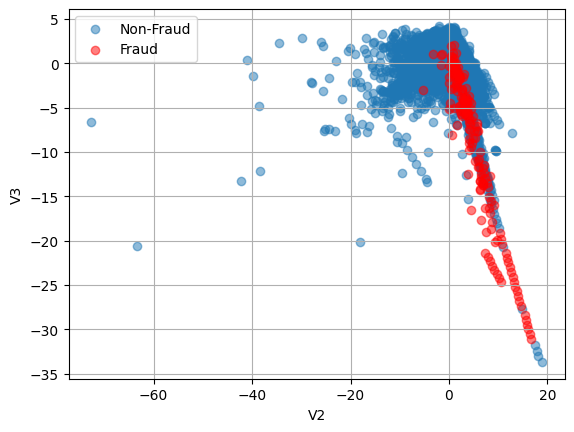

In [28]:
plt.scatter(df.V2[df.Class == 0], df.V3[df.Class == 0], label="Non-Fraud", alpha=0.5)
plt.scatter(df.V2[df.Class == 1], df.V3[df.Class == 1], label="Fraud", alpha=0.5, c='r')
plt.legend()
plt.xlabel('V2')
plt.ylabel('V3')
plt.grid()
#plt.show()
#plt.savefig('V2V3')

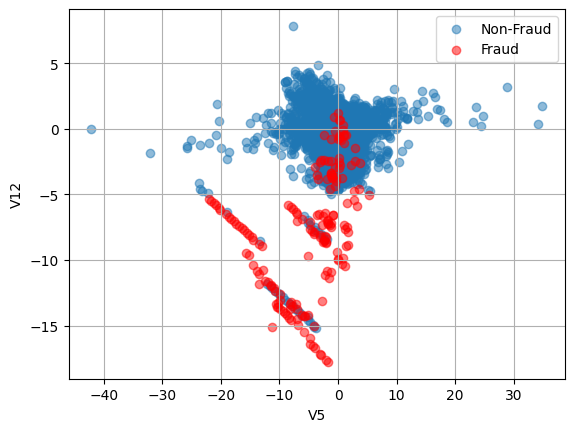

In [29]:
plt.scatter(df.V5[df.Class == 0], df.V12[df.Class == 0], label="Non-Fraud", alpha=0.5)
plt.scatter(df.V5[df.Class == 1], df.V12[df.Class == 1], label="Fraud", alpha=0.5, c='r')
plt.legend()
plt.xlabel('V5')
plt.ylabel('V12')
plt.grid()
#plt.show()
#plt.savefig('V5V12')

In [30]:
df = df.dropna()
X = df.iloc[:,:29].values
y = df['Class'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# R^2 metric
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test, y_pred))

0.5828965965636532
0.0011438124759820959


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1
                                                   )
model = DecisionTreeClassifier()#criterion = 'entropy', max_depth = 3)
model = model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.9990351681219547


In [32]:
cross_val_score(model, X, y, cv=10)

array([0.99913169, 0.99667149, 0.99797395, 0.99913169, 0.99797366,
       0.99898683, 0.99956578, 0.99971052, 0.99855261, 0.99869735])

[Text(0.18163822263222631, 0.9666666666666667, 'X[11] <= -5.005\ngini = 0.005\nsamples = 48365\nvalue = [48239, 126]'),
 Text(0.07872078720787208, 0.9, 'X[25] <= -0.275\ngini = 0.381\nsamples = 117\nvalue = [30, 87]'),
 Text(0.03936039360393604, 0.8333333333333334, 'X[26] <= 0.647\ngini = 0.271\nsamples = 31\nvalue = [26, 5]'),
 Text(0.01968019680196802, 0.7666666666666667, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.05904059040590406, 0.7666666666666667, 'gini = 0.0\nsamples = 26\nvalue = [26, 0]'),
 Text(0.11808118081180811, 0.8333333333333334, 'X[19] <= 1.787\ngini = 0.089\nsamples = 86\nvalue = [4, 82]'),
 Text(0.0984009840098401, 0.7666666666666667, 'X[12] <= -1.579\ngini = 0.068\nsamples = 85\nvalue = [3, 82]'),
 Text(0.07872078720787208, 0.7, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.11808118081180811, 0.7, 'X[27] <= 0.87\ngini = 0.046\nsamples = 84\nvalue = [2, 82]'),
 Text(0.07872078720787208, 0.6333333333333333, 'X[19] <= 1.71\ngini = 0.024\nsamples = 81\nva

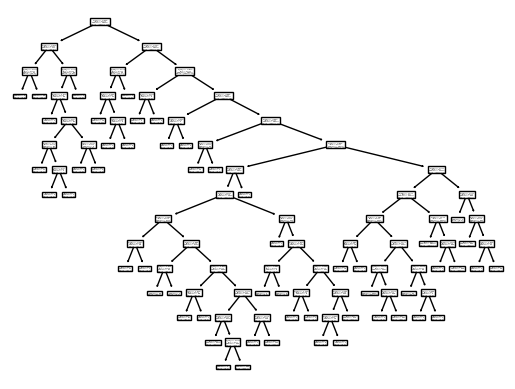

In [33]:
 tree.plot_tree(model)

In [34]:
# Define the model as the random forest
model = RandomForestClassifier(random_state=3, n_estimators=28)
model.fit(X_train, y_train)
predicted = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.9990351681219547


In [35]:
cross_val_score(model, X, y, cv=10)

array([0.99942113, 0.99667149, 0.99797395, 0.99927641, 0.99869735,
       0.99927631, 0.99971052, 1.        , 0.99927631, 0.99797366])